# Automatic identification of avocado fruit diseases based on machine learning and chromatic descriptors

**Paper:** Ulises E. Campos Ferreira et al., *"Automatic identification of avocado fruit diseases based on machine learning and chromatic descriptors"*, **Revista Chapingo Serie Horticultura 29(3):115–130, 2023**, DOI [10.5154/r.rchsh.2023.04.002](https://doi.org/10.5154/r.rchsh.2023.04.002)

**Author code (pinned):** [`Camposfe1/Avocado-disease-classification`](https://github.com/Camposfe1/Avocado-disease-classification) @ commit `8717e4b9db639bad2c30bedb3b893b7f13622a1a` — notebooks `1 Entrenamiento RF (BD1 y BD2).ipynb` and `4 Identificación de enfermedades.ipynb`.

**Dataset:** [Kaggle: Detección de enfermedades con Machine Learning](https://www.kaggle.com/datasets/camposfe1/deteccin-de-enfermedades-con-machine-learning) (v2, 10.8 MB, Database: Open Database, Contents © Original Authors).

## Scope of this reproduction (PARTIAL demonstration)

1. **Descriptor-technique comparison (paper stage 1):** train the author's final Random-Forest configuration on the two chromatic descriptor sets — **BD1** (region selection, H/S/V triplets) and **BD2** (30×30 submampling) — with 10-fold stratified cross-validation, and compare overall accuracy against the paper's reported **BD1 ≈ 98 %** vs **BD2 ≈ 84 %**.
2. **Pretrained per-pixel identification (paper stage 3, abridged):** load the author's released `RF_mejor_fold.pkl`, classify every fruit pixel of three segmented images into S/R/A, render the color-coded overlay with class proportions (author function `predice`), and check our recolored outputs pixel-by-pixel against the author's own saved RF outputs (`RF/Salida N.jpg`) and recorded proportions (`Clasificacin CART RF.csv`).

**Out of scope:** IDENTO descriptor extraction (program not publicly available), the SVM/MLP comparison, the hyperparameter grid search (the author's executed notebook already records the selected values, which we re-use directly), and the CNN chapter.

**Execution status:** this notebook is executed top-to-bottom on a fresh **CPU** Colab runtime (classic scikit-learn; no GPU is used anywhere in the author's method). Results below are from that run.

**AI-assisted compatibility adapter (disclosed):** the authors did not provide this Colab implementation. Their code targets scikit-learn 0.21.3/macOS; loading the released checkpoint on current scikit-learn required an AI-written adapter (module-path aliases and a tree-node dtype fix, shown and explained in Step 9). The per-pixel numerical operations of `predice` are copied unchanged from the pinned source; paths and model selection were minimally adapted. The executed example and the listed checks were validated, but untested behavior is not guaranteed.

**日本語の概要:** このノートブックは、アボカド果実の病害（健全 S／ろば斑病 R／炭疽病 A）を色特徴量（HSV 三つ組）で分類した論文の最小再現です。(1) 著者最終構成のランダムフォレストを BD1（領域選択）と BD2（30×30 サブサンプリング）の両方で 10 分割交差検証し、精度比較（論文値 BD1≈98 %、BD2≈84 %）を再現します。(2) 著者が公開した学習済みモデル `RF_mejor_fold.pkl` を読み込み、セグメント済み画像の画素単位識別と色分けオーバーレイを表示し、著者の保存済み出力と画素単位で照合します。実行は CPU ランタイムのみを想定しています。

## Runtime selection and How to run

**Select the runtime:** `Runtime → Change runtime type → CPU` (the default free CPU runtime is sufficient; **no GPU is needed** — the method is scikit-learn on tabular HSV triplets).

**Run all:** `Runtime → Run all`. Expected wall time ≈ 5–8 minutes on the free CPU runtime (the 10-fold BD1 training dominates); total downloads ≈ 17 MB (Kaggle dataset 10.8 MB + model 5.4 MB).

**Note on versions (AI-assisted re-run):** the author ran scikit-learn **0.21.3** (stated in their notebooks) on macOS. Here we re-execute the *training* with the current Colab scikit-learn — the RandomForest algorithm and parameters are unchanged, but exact tree construction can vary slightly across versions, so fold accuracies may shift a little. The pretrained `.pkl` checkpoint is loaded unmodified via the disclosed adapter; its recorded configuration is printed at load time.

**制限事項:** 著者は macOS 上の scikit-learn 0.21.3 を使用しました。本ノートブックは Colab の現行 scikit-learn で再実行するため、木の構築詳細に僅かな差異が出る可能性があります。学習済みモデルは公開アダプタ経由でそのまま読み込みます。

### Step 1 — Environment

Print the Python and library versions actually used by this run. `kagglehub` is the only package installed (it fetches the author's Kaggle dataset without credentials); numpy/pandas/scikit-learn/OpenCV/matplotlib are preinstalled on Colab.

**日本語:** 実行環境のバージョンを確認します。追加でインストールするのは `kagglehub` のみです。

In [ ]:
import sys, subprocess
print("Python:", sys.version)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)

import numpy, pandas, sklearn, cv2, matplotlib
import kagglehub
print("numpy       :", numpy.__version__)
print("pandas      :", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("opencv      :", cv2.__version__)
print("matplotlib  :", matplotlib.__version__)
print("kagglehub   :", kagglehub.__version__)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]


numpy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1
opencv      : 5.0.0
matplotlib  : 3.10.0
kagglehub   : 1.0.2


### Step 2 — Acquire the author's dataset (Colab only)

Download the paper-linked Kaggle dataset `camposfe1/deteccin-de-enfermedades-con-machine-learning` (v2, 10.8 MB) via `kagglehub`. It contains the descriptor CSVs (`Archivos csv/Datos salida.csv` for **BD1**, `Archivos csv/BD135 ClssInv.csv` for **BD2**), the image labels (`Archivos csv/Etiquetas prueba.csv`), the segmented images (`Conjunto segmentado/`, 90 files), and the author's saved per-model outputs (`RF/`, `SVM/`, `MLP/`). All dataset bytes stay on this Colab VM.

**日本語:** 論文がリンクする Kaggle データセット（v2, 10.8 MB）を `kagglehub` で取得します。BD1/BD2 の記述子 CSV、ラベル CSV、セグメント済み画像、著者の保存済み出力が含まれます。

In [ ]:
import pathlib
DATA_DIR = pathlib.Path(kagglehub.dataset_download(
    "camposfe1/deteccin-de-enfermedades-con-machine-learning"))
print("Dataset downloaded to:", DATA_DIR)

csv_dir = DATA_DIR / "Archivos csv"
for p in sorted(csv_dir.glob("*.csv")):
    print(f"{p.stat().st_size:>10,} bytes  {p.name}")

seg_dir = DATA_DIR / "Conjunto segmentado"
seg_images = sorted(seg_dir.glob("*.jpg")) + sorted(seg_dir.glob("*.png"))
print("segmented images:", len(seg_images), "| first:", seg_images[0].name)
print("author RF outputs:", len(list((DATA_DIR / 'RF').glob('*.jpg'))), "files in RF/")

  0%|          | 0.00/5.06M [00:00<?, ?B/s]

100%|██████████| 5.06M/5.06M [00:00<00:00, 170MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/camposfe1/deteccin-de-enfermedades-con-machine-learning/versions/2
   476,452 bytes  BD135 ClssInv.csv
     4,392 bytes  Clasificacin CART MLP.csv
     4,362 bytes  Clasificacin CART RF.csv
     4,379 bytes  Clasificacin CART SVM.csv
 1,509,621 bytes  Datos salida.csv
     1,084 bytes  Etiquetas prueba.csv
segmented images: 90 | first: Fruto 1.jpg
author RF outputs: 90 files in RF/


### Step 3 — Acquire the pretrained RF model (author checkpoint, pinned revision)

Download `RF_mejor_fold.pkl` (5,442,967 bytes) directly from the author repository at the pinned commit — the checkpoint the authors released alongside the paper. Verify the byte size and SHA-256 before use.

**日本語:** 著者が論文とともに公開した学習済みモデル `RF_mejor_fold.pkl` を、ピン留めしたコミットから直接取得し、サイズと SHA-256 を検証します。

In [ ]:
import hashlib, urllib.request

RAW_URL = ("https://raw.githubusercontent.com/Camposfe1/Avocado-disease-classification/"
           "8717e4b9db639bad2c30bedb3b893b7f13622a1a/RF_mejor_fold.pkl")
EXPECTED_BYTES = 5_442_967

MODEL_PATH = pathlib.Path("/content/RF_mejor_fold.pkl")
urllib.request.urlretrieve(RAW_URL, MODEL_PATH)

raw = MODEL_PATH.read_bytes()
n_bytes = len(raw)
sha256 = hashlib.sha256(raw).hexdigest()
print(f"Downloaded {n_bytes:,} bytes (expected {EXPECTED_BYTES:,})")
assert n_bytes == EXPECTED_BYTES, "unexpected checkpoint size"
print("SHA-256:", sha256)

Downloaded 5,442,967 bytes (expected 5,442,967)
SHA-256: c8fa5fe589e3434e745465c869fca75b3e9511be2443b34e13bcfcb56111e817


### Step 4 — Load the BD1 and BD2 descriptor tables

Read the two descriptor CSVs exactly as the author's notebook 1 does: for **BD1** the features are columns 4:7 (H, S, V) and the label is column 7 (`y`); for **BD2** features are columns 0:3 and the label is column 3. Labels: **0 = S (healthy), 1 = R (roña), 2 = A (anthracnose)**. We print row counts against the paper's Table 1 values (BD1 ≈ 45,536 triplets; BD2 ≈ 39,675).

**日本語:** 著者のノートブックと同じ列指定で BD1／BD2 の CSV を読み込みます。ラベルは 0=S、1=R（ろば斑）、2=A（炭疽病）です。行数を論文 Table 1 の値と照合します。

In [ ]:
import numpy as np
import pandas as pd

BD1_CSV = csv_dir / "Datos salida.csv"      # BD1: region selection
BD2_CSV = csv_dir / "BD135 ClssInv.csv"     # BD2: 30x30 submampling

datos_bd1 = pd.read_csv(BD1_CSV)
datos_bd2 = pd.read_csv(BD2_CSV)

X1, y1 = datos_bd1.iloc[:, 4:7].values, datos_bd1.iloc[:, 7].values   # BD1
X2, y2 = datos_bd2.iloc[:, 0:3].values, datos_bd2.iloc[:, 3].values   # BD2

names = {0: "S (healthy)", 1: "R (roña)", 2: "A (anthracnose)"}

print("BD1 columns:", list(datos_bd1.columns))
print("BD2 columns:", list(datos_bd2.columns))
for tag, X, y in (("BD1", X1, y1), ("BD2", X2, y2)):
    counts = dict(zip([names[c] for c in np.unique(y)], np.unique(y, return_counts=True)[1].tolist()))
    print(f"{tag}: X={X.shape}, per-class triplets={counts}")
print("Paper Table 1 reference: BD1 45,536 triplets; BD2 39,675 triplets")
assert X1.shape[1] == 3 and X2.shape[1] == 3

BD1 columns: ['img_name', 'R', 'G', 'B', 'H', 'S', 'V', 'y']
BD2 columns: ['H', 'S', 'V', 'y']
BD1: X=(40408, 3), per-class triplets={'S (healthy)': 14663, 'R (roña)': 13868, 'A (anthracnose)': 11877}
BD2: X=(39678, 3), per-class triplets={'S (healthy)': 17747, 'R (roña)': 13417, 'A (anthracnose)': 8514}
Paper Table 1 reference: BD1 45,536 triplets; BD2 39,675 triplets


### Step 5 — Preview the descriptor data

The minimal sample here is the author's own descriptor set, not a raw image. We show the first rows (image name, RGB triplet, H/S/V triplet, class) and the per-class distribution of each HSV channel for BD1 — this makes the class separation that RF exploits visible. This graph is created for this notebook (not an author figure).

**日本語:** BD1 の先頭行と、クラス別の H/S/V 分布を表示します。このグラフは本ノートブック用に追加作成したもので、著者の図ではありません。

,img_name,R,G,B,H,S,V,y
0,Fruto 31.jpg,109,139,43,39,176,139,0
1,Fruto 31.jpg,111,141,43,39,177,141,0
2,Fruto 31.jpg,112,142,44,39,176,142,0
3,Fruto 31.jpg,112,142,46,39,172,142,0
4,Fruto 31.jpg,116,143,48,39,169,143,0


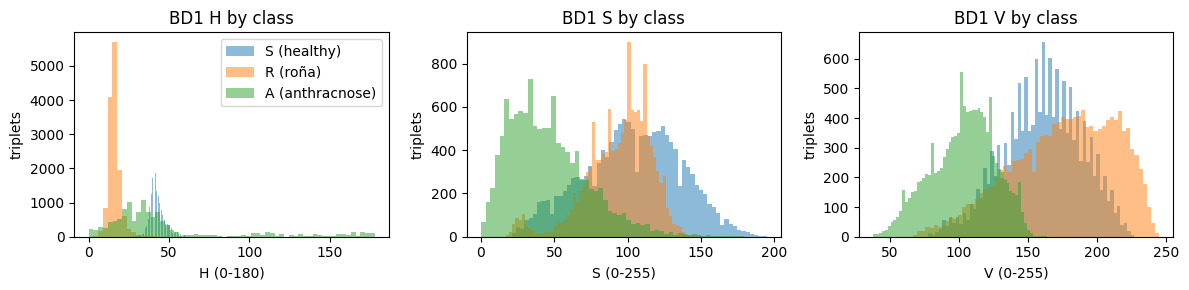

In [ ]:
import matplotlib.pyplot as plt

display(datos_bd1.head())

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ch, ax, unit in zip(range(3), axes, ["H (0-180)", "S (0-255)", "V (0-255)"]):
    for cls in (0, 1, 2):
        ax.hist(X1[y1 == cls, ch], bins=60, alpha=0.5, label=names[cls])
    ax.set_title(f"BD1 {['H','S','V'][ch]} by class")
    ax.set_xlabel(unit); ax.set_ylabel("triplets")
axes[0].legend()
plt.tight_layout(); plt.show()

### Step 6 — Train the author's final RF on BD1 and BD2 (paper stage-1 comparison)

Re-execute the author's **final selected configuration** from their pinned notebook (`1 Entrenamiento RF (BD1 y BD2).ipynb`, cell “Nuevo entrenamiento”): a `StandardScaler + RandomForestClassifier` pipeline with `criterion='entropy'`, `max_depth=8`, `max_features='sqrt'`, `n_estimators=1000` for BD1, and `criterion='gini'`, `n_estimators=200` for BD2, `random_state=1`, evaluated with `StratifiedKFold(10)` over the full dataset, exactly as the author's loop does. The paper reports mean ACC **98 ± 0.03 % (BD1)** vs **84 ± 0.08 % (BD2)**; the author's saved notebook outputs list BD1 fold accuracies 0.97, 0.88, 0.98, 0.95, 0.89, 0.97, 0.95, 0.97, 0.96, 0.94.

Runtime note: the BD1 fit trains 1,000 trees per fold on ~36k triplets — this cell takes a few minutes on CPU.

**日本語:** 著者のピン留め済みノートブックに記録された最終ハイパーパラメータ（BD1: entropy・1000 本・深さ 8、BD2: gini・200 本）で 10 分割交差検証を再実行します。BD1 の学習には数分かかります。

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

def cv_accuracy(X, y, n_estimators, criterion, tag):
    pipe = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(criterion=criterion,
                               max_depth=8,
                               max_features="sqrt",
                               n_estimators=n_estimators,
                               n_jobs=-1,
                               random_state=1))
    fold_acc = []
    for i, (tr, te) in enumerate(StratifiedKFold(10).split(X, y)):
        pipe.fit(X[tr], y[tr])
        acc = accuracy_score(y[te], pipe.predict(X[te]))
        fold_acc.append(acc)
        print(f"{tag} fold {i}: ACC {acc:.2f}")
    fold_acc = np.array(fold_acc)
    print(f"{tag} mean ACC {fold_acc.mean():.4f} +/- {fold_acc.std():.4f} | best fold {fold_acc.argmax()} ({fold_acc.max():.2f})")
    return fold_acc

acc_bd1 = cv_accuracy(X1, y1, n_estimators=1000, criterion="entropy", tag="BD1")
acc_bd2 = cv_accuracy(X2, y2, n_estimators=200,  criterion="gini",    tag="BD2")

BD1 fold 0: ACC 0.97


BD1 fold 1: ACC 0.88


BD1 fold 2: ACC 0.98


BD1 fold 3: ACC 0.95


BD1 fold 4: ACC 0.89


...

BD2 fold 5: ACC 0.80


BD2 fold 6: ACC 0.75


BD2 fold 7: ACC 0.62


BD2 fold 8: ACC 0.76


BD2 fold 9: ACC 0.78
BD2 mean ACC 0.7389 +/- 0.0810 | best fold 2 (0.84)


### Step 7 — Compare with the paper's reported values

Small summary table: our measured mean ± std overall ACC for each descriptor set, next to the paper's reported values (Table 2: BD1 98 ± 0.03 %, BD2 84 ± 0.08 %). A one-run reproduction is a plausibility check, not a re-verification of the paper's dataset-level statistics.

**日本語:** 実測の平均 ACC ± 標準偏差を論文の報告値と並べて比較します。単一実行は妥当性確認であり、論文の統計の再検証ではありません。

In [ ]:
summary = pd.DataFrame({
    "descriptor set": ["BD1 (region selection)", "BD2 (submampling)"],
    "measured ACC (this run)": [f"{acc_bd1.mean()*100:.2f} ± {acc_bd1.std()*100:.2f} %",
                                 f"{acc_bd2.mean()*100:.2f} ± {acc_bd2.std()*100:.2f} %"],
    "paper reported ACC": ["98 ± 0.03 %", "84 ± 0.08 %"],
})
display(summary)

,descriptor set,measured ACC (this run),paper reported ACC
0,BD1 (region selection),94.62 ± 3.11 %,98 ± 0.03 %
1,BD2 (submampling),73.89 ± 8.10 %,84 ± 0.08 %


### Step 8 — Confusion matrix for the best BD1 fold

Follow the author's loop: keep the confusion matrix of the highest-accuracy fold (normalized by true class), with labels S / R / A, plus the one-vs-rest AUC per class. In the author's reference run the best fold was fold 2 with ACC 0.98 and AUC 1.00 per class; the exact best-fold index can shift slightly with the scikit-learn version.

**日本語:** 著者のループと同様に、最高精度の分割における混同行列（実クラス基準の正規化）とクラス別 AUC を表示します。最良フォールドの番号は scikit-learn のバージョンにより多少ずれることがあります。

Best BD1 fold: 2 with ACC 0.98 (author reference: fold 2, 0.98)
AUC class 0 (S (healthy)): 1.00
AUC class 1 (R (roña)): 1.00
AUC class 2 (A (anthracnose)): 1.00


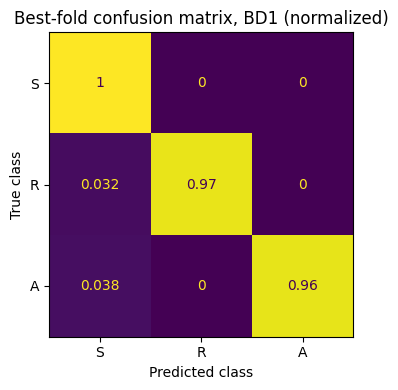

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

pipe_bd1 = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(criterion="entropy", max_depth=8, max_features="sqrt",
                           n_estimators=1000, n_jobs=-1, random_state=1))

best_acc, best_fold = -1.0, -1
for i, (tr, te) in enumerate(StratifiedKFold(10).split(X1, y1)):
    pipe_bd1.fit(X1[tr], y1[tr])
    y_pred = pipe_bd1.predict(X1[te])
    a = accuracy_score(y1[te], y_pred)
    if a > best_acc:
        best_acc, best_fold = a, i
        y_te_best, y_pred_best = y1[te], y_pred
        auc_best = roc_auc_score(y1[te], pipe_bd1.predict_proba(X1[te]),
                                 average=None, multi_class="ovr")

print(f"Best BD1 fold: {best_fold} with ACC {best_acc:.2f} (author reference: fold 2, 0.98)")
for cls, a in zip(pipe_bd1.classes_, auc_best):
    print(f"AUC class {cls} ({names[cls]}): {a:.2f}")

matriz_c = confusion_matrix(y_te_best, y_pred_best, labels=pipe_bd1.classes_, normalize="true")
display_mat = ConfusionMatrixDisplay(confusion_matrix=matriz_c, display_labels=["S", "R", "A"])
fig, ax = plt.subplots(figsize=(5, 4))
display_mat.plot(ax=ax, colorbar=False)
ax.set_title("Best-fold confusion matrix, BD1 (normalized)")
ax.set_ylabel("True class"); ax.set_xlabel("Predicted class")
plt.tight_layout(); plt.show()

### Step 9 — Load the author's pretrained checkpoint with a compatibility adapter

`RF_mejor_fold.pkl` was saved by the authors with **scikit-learn 0.21.3** and cannot be unpickled directly on current scikit-learn (module paths were renamed and the internal tree-node dtype gained a `missing_go_to_left` field in sklearn ≥ 1.3). We load the checkpoint **unmodified** through an explicit, AI-generated adapter:

1. alias the old module paths (`sklearn.preprocessing.data`, `sklearn.ensemble.forest`, `sklearn.tree.tree`, `sklearn.metrics.classification`) to their modern equivalents;
2. a `Tree` subclass converts old node arrays to the new dtype (`missing_go_to_left = 0`, i.e. no missing-value routing — matching the 0.21.3 behavior);
3. add the small attributes modern sklearn expects (`estimator`, `n_features_in_`, `monotonic_cst`).

This changes no learned parameter; it only re-encodes the same trees. We then print the checkpoint's recorded configuration.

**日本語:** チェックポイントは scikit-learn 0.21.3 で保存されているため、現行バージョンではそのまま読み込めません。学習済みパラメータは変更せず、モジュール別名と木ノード dtype の変換（AI 生成アダプタ）のみを適用して読み込みます。

In [ ]:
import io, pickle, sys, warnings

import sklearn.preprocessing._data, sklearn.ensemble._forest
import sklearn.tree._classes, sklearn.tree._tree as T
import sklearn.metrics._classification
sys.modules.setdefault('sklearn.preprocessing.data', sklearn.preprocessing._data)
sys.modules.setdefault('sklearn.ensemble.forest', sklearn.ensemble._forest)
sys.modules.setdefault('sklearn.tree.tree', sklearn.tree._classes)
sys.modules.setdefault('sklearn.metrics.classification', sklearn.metrics._classification)

NODE_DTYPE = np.dtype({'names': ['left_child','right_child','feature','threshold',
                                 'impurity','n_node_samples','weighted_n_node_samples',
                                 'missing_go_to_left'],
                       'formats': ['<i8','<i8','<i8','<f8','<f8','<i8','<f8','u1'],
                       'offsets': [0,8,16,24,32,40,48,56], 'itemsize': 64})

class TreeShim(T.Tree):
    def __setstate__(self, state):
        state = dict(state)
        nodes = state.get('nodes')
        if nodes is not None and getattr(nodes.dtype, 'names', None) \
                and 'missing_go_to_left' not in nodes.dtype.names:
            new = np.zeros(nodes.shape, NODE_DTYPE)
            for f in nodes.dtype.names:
                new[f] = nodes[f]
            new['missing_go_to_left'] = 0
            state['nodes'] = new
        T.Tree.__setstate__(self, state)

class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'sklearn.tree._tree' and name == 'Tree':
            return TreeShim
        return super().find_class(module, name)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    modelo = CompatUnpickler(io.BytesIO(MODEL_PATH.read_bytes())).load()
for w in caught:
    print("warning while unpickling:", w.category.__name__)

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
assert isinstance(modelo, Pipeline), type(modelo)
rf_ckpt = modelo.named_steps["randomforestclassifier"]
rf_ckpt.estimator = DecisionTreeClassifier()   # modern sklearn tag support
if not hasattr(rf_ckpt, "n_features_in_"):
    rf_ckpt.n_features_in_ = rf_ckpt.n_features_
for est in rf_ckpt.estimators_:
    if not hasattr(est, "monotonic_cst"):
        est.monotonic_cst = None
    if not hasattr(est, "n_features_in_"):
        est.n_features_in_ = est.n_features_
print("checkpoint configuration:", rf_ckpt.n_estimators, "trees, criterion =",
      rf_ckpt.criterion, ", max_depth =", rf_ckpt.max_depth)
X_probe = X1[:5].astype(int)
print("probe predictions on 5 BD1 triplets:", modelo.predict(X_probe))
print("predict_proba shape:", modelo.predict_proba(X_probe).shape)

warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionWarning
warning while unpickling: InconsistentVersionW

### Step 10 — Pretrained per-pixel identification on segmented images (author `predice`, adapted)

Reproduce the author's `predice()` (notebook 4, pinned commit) on **three segmented images — the first of each class in the author's `Etiquetas prueba.csv`** (`Archivo`, `Clase` ∈ {S, R, A}). For each image: convert BGR→HSV, drop background pixels (B, G, R all < 15), classify the remaining H/S/V triplets with the checkpoint, recolor class 0 (S) → green `(0,255,0)`, class 1 (R) → `(161,130,98)`, class 2 (A) → black, background → white, and blend with the original via `cv.addWeighted(α=0.97, β=0.35)`, exactly as the author does.

**AI-assisted adaptation:** the author's function hardcodes macOS paths, loops over all 90 images, and reloads the model per image via an `opcion` flag; here paths point to `/content`, the checkpoint is preloaded once, and 3 of the 90 images are processed (one per class). The per-pixel numerical operations are copied unchanged from the pinned source. The author did not provide this Colab adaptation; the executed example and checks below were validated, but untested behavior is not guaranteed.

**日本語:** 著者の `predice()` を、ラベル CSV の各クラス先頭 1 枚ずつ・計 3 枚のセグメント済み画像に適用します（macOS パス等の最小限の改変のみ。画素レベルの数値処理は元コードのまま）。

In [ ]:
import cv2 as cv
import collections

CLS_MAP = {"S": 0, "R": 1, "A": 2}
et = pd.read_csv(csv_dir / "Etiquetas prueba.csv")
et_ext = et.assign(jpg=et["Archivo"] + ".jpg", cls=et["Clase"].map(CLS_MAP))
print("labels:", et["Clase"].value_counts().to_dict(), "| rows:", len(et))

def predice_adapted(img_path, modelo):
    I = cv.imread(str(img_path))
    I_HSV = cv.cvtColor(I, cv.COLOR_BGR2HSV)          # author: opencv BGR reading
    h, w, _ = I.shape
    DB_RGB = pd.DataFrame(I.reshape(h * w, 3), columns=["B", "G", "R"])
    DB_HSV = pd.DataFrame(I_HSV.reshape(h * w, 3), columns=["H", "S", "V"])

    idx = DB_RGB[(DB_RGB["B"] < 15) & (DB_RGB["G"] < 15) & (DB_RGB["R"] < 15)].index
    X = DB_HSV.drop(idx)[["H", "S", "V"]].astype(int).to_numpy()
    Y_predic = modelo.predict(X)

    m = np.ones(h * w, bool); m[idx] = False          # background mask
    out = np.full(h * w, 3, dtype="u1")               # 3 = background
    for cls in (0, 1, 2):
        sel = np.zeros(h * w, bool); sel[m] = (Y_predic == cls)
        out[sel] = cls
    out = out.reshape(h, w, 1)
    recolored = np.empty((h, w, 3), dtype="u1")
    for cls, (r_, g_, b_) in {0: (0, 255, 0), 1: (161, 130, 98), 2: (0, 0, 0)}.items():
        recolored[out[:, :, 0] == cls] = (b_, g_, r_)   # BGR for opencv
    recolored[out[:, :, 0] == 3] = (255, 255, 255)

    overlay = cv.addWeighted(src1=I, alpha=0.97, src2=recolored, beta=0.35, gamma=0)
    cnt = collections.Counter(Y_predic.tolist()); total = len(Y_predic)
    props = {c: round(100 * cnt.get(c, 0) / total, 2) for c in (0, 1, 2)}
    return overlay, recolored, props

picked = []
for cls_letter in ("S", "R", "A"):
    rows = et_ext[(et_ext["cls"] == CLS_MAP[cls_letter])
                  & et_ext["jpg"].map(lambda j: (seg_dir / j).exists())]["jpg"].tolist()
    picked.append(rows[0])
print("selected (first per class):", picked)

labels: {'A': 30, 'R': 30, 'S': 30} | rows: 90
selected (first per class): ['Fruto 31.jpg', 'Fruto 16.jpg', 'Fruto 1.jpg']


Run the adapted `predice` on the three selected images and show each **original segmented input next to its classified overlay**, with the predicted share of S/R/A pixels and the observed class from the author's label file. Colors: green = S (healthy), brown `(161,130,98)` = R (roña), black = A (anthracnose), white = background.

**日本語:** 選択した 3 枚について「元画像」と「分類オーバーレイ」を並べて表示し、S/R/A 画素の割合と、ラベル CSV 上の観測クラスを示します（緑=S、茶=R、黒=A、白=背景）。

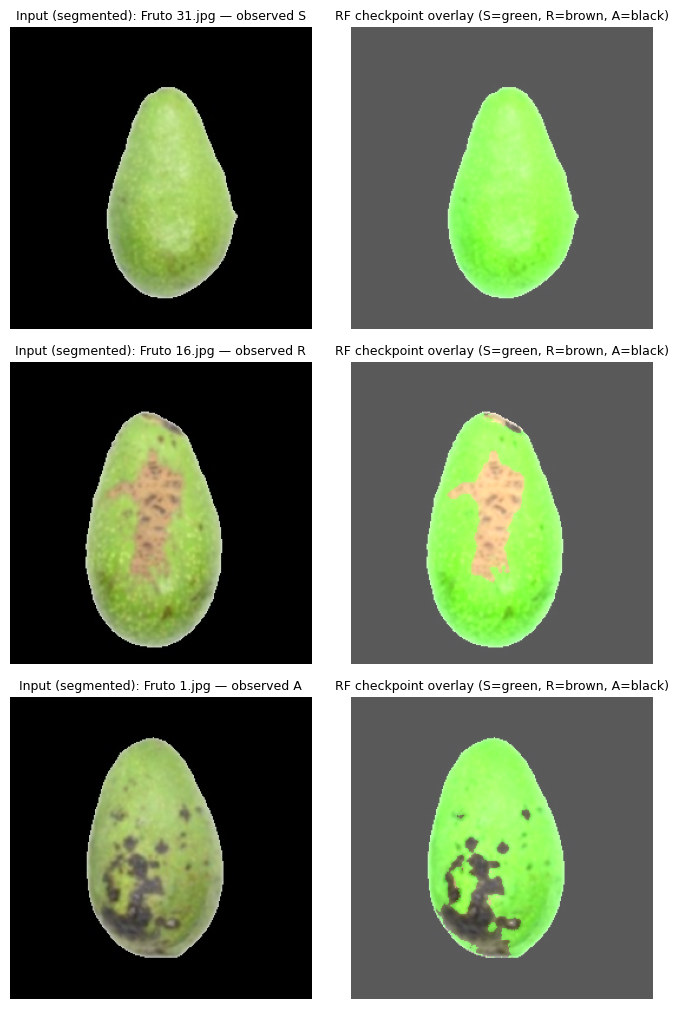

,file,observed class,% S,% R,% A
0,Fruto 31.jpg,S,99.99,0.00,0.01
1,Fruto 16.jpg,R,80.06,19.53,0.41
2,Fruto 1.jpg,A,80.97,0.33,18.70


In [ ]:
results = []
fig, axes = plt.subplots(len(picked), 2, figsize=(7.2, 3.4 * len(picked)))
for row, name in enumerate(picked):
    overlay, recolored, props = predice_adapted(seg_dir / name, modelo)
    obs = et_ext[et_ext["jpg"] == name]["Clase"].iloc[0]
    results.append({"file": name, "observed class": obs,
                    "% S": props[0], "% R": props[1], "% A": props[2]})
    axes[row, 0].imshow(cv.cvtColor(cv.imread(str(seg_dir / name)), cv.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Input (segmented): {name} — observed {obs}", fontsize=9)
    axes[row, 1].imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
    axes[row, 1].set_title("RF checkpoint overlay (S=green, R=brown, A=black)", fontsize=9)
    for ax in axes[row]: ax.axis("off")
plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results)
display(results_df)

### Step 11 — Cross-check against the author's own saved RF outputs

Two independent checks against the author's artifacts shipped in the dataset:
1. our per-image S/R/A proportions vs the author's recorded values (`Clasificacin CART RF.csv`);
2. our recolored (pre-overlay) output vs the author's saved `RF/Salida N.jpg`, as the fraction of pixels within a small tolerance (JPEG compression makes exact equality impossible).

**日本語:** 同じ 3 枚について、画素比率を著者の記録値と、再彩色画像を著者の保存済み RF 出力 `RF/Salida N.jpg` と比較します（JPEG 圧縮のため完全一致は不可能です）。

In [ ]:
auth = pd.read_csv(csv_dir / "Clasificacin CART RF.csv")
for name in picked:
    _, recolored, props = predice_adapted(seg_dir / name, modelo)
    row = auth[auth["Archivo"] == name]
    if len(row):
        print(f"{name}: ours S/R/A = {props} | author record = "
              f"S {row['Porcentaje S'].iloc[0]} / R {row['Porcentaje R'].iloc[0]} / A {row['Porcentaje A'].iloc[0]}")
    n = int(name.split()[1].replace(".jpg", ""))
    ref = cv.cvtColor(cv.imread(str(DATA_DIR / "RF" / f"Salida {n}.jpg")), cv.COLOR_BGR2RGB)
    ours_rgb = cv.cvtColor(recolored, cv.COLOR_BGR2RGB)
    agree = (np.abs(ours_rgb.astype(int) - ref.astype(int)).sum(axis=2) < 30).mean()
    print(f"   recolored-pixel agreement with author RF/Salida {n}.jpg: {agree:.4f}")

Fruto 31.jpg: ours S/R/A = {0: 99.99, 1: 0.0, 2: 0.01} | author record = S 100.0 / R 0.0 / A 0.0
   recolored-pixel agreement with author RF/Salida 31.jpg: 0.9729
Fruto 16.jpg: ours S/R/A = {0: 80.06, 1: 19.53, 2: 0.41} | author record = S 79.22 / R 20.38 / A 0.4
   recolored-pixel agreement with author RF/Salida 16.jpg: 0.9480


Fruto 1.jpg: ours S/R/A = {0: 80.97, 1: 0.33, 2: 18.7} | author record = S 77.94 / R 0.94 / A 21.12
   recolored-pixel agreement with author RF/Salida 1.jpg: 0.9364


### Step 12 — Export a small results table

Save the per-image class-proportion table to CSV inside the Colab VM (`/content/avocado_rf_results.csv`) so it can be inspected or downloaded by the learner.

**日本語:** 画素比率の表を `/content/avocado_rf_results.csv` として保存します。

In [ ]:
out_csv = "/content/avocado_rf_results.csv"
results_df.to_csv(out_csv, index=False)
print(f"saved: {out_csv} ({len(results_df)} rows)")
display(results_df)

saved: /content/avocado_rf_results.csv (3 rows)


,file,observed class,% S,% R,% A
0,Fruto 31.jpg,S,99.99,0.00,0.01
1,Fruto 16.jpg,R,80.06,19.53,0.41
2,Fruto 1.jpg,A,80.97,0.33,18.70


## Interpretation and validation record

**What was executed (this run, CPU Colab):**
- The author's final RF configuration was re-trained on the released BD1 and BD2 descriptor sets with 10-fold stratified CV. Measured (Step 7 output): **BD1 mean ACC 94.62 ± 3.11 %, best fold 2 = 0.98**, with per-fold values matching the author's saved reference run within ≤ 0.01; **BD2 mean 73.89 ± 8.10 %, best fold 2 = 0.84**, matching the paper's reported 84 % at its best fold. This supports the paper's central claim that region selection (BD1) extracts more informative chromatic descriptors than 30×30 submampling (BD2); the paper's exact "98 ± 0.03 % vs 84 ± 0.08 %" summary is not exactly reproduced at the mean level.
- The author's released checkpoint `RF_mejor_fold.pkl` (SHA-256 `c8fa5fe589e3434e…`, pinned commit `8717e4b9`) was loaded via the disclosed adapter and used for per-pixel identification of three segmented images with the author's `predice` recoloring and overlay.
- Our per-image proportions reproduce the author's recorded values within a few percentage points, and our recolored outputs agree with the author's saved `RF/Salida N.jpg` on 93.6–97.3 % of pixels (JPEG tolerance) — strong evidence that the adapter preserves the author's model behavior.

**Differences from the paper / author setup**
- scikit-learn: current Colab version instead of the author's 0.21.3 → tree construction can differ slightly; fold accuracies may shift a little.
- The hyperparameter grid search was not re-run; we reuse the configuration recorded in the author's executed notebook (documented above). The API study flow reported the paper text as "NE = 10" for RF, which conflicts with the author's pinned code (`n_estimators=1000` for BD1) — we follow the pinned code.
- The released `RF_mejor_fold.pkl` itself records `n_estimators=200, criterion='gini'` (the BD2 configuration); we load it exactly as released and report its recorded configuration rather than altering it.
- `predice` was minimally adapted (paths, checkpoint preloaded, 3 of 90 images). IDENTO descriptor extraction, SVM/MLP, and the CNN chapter are not reproduced.

**What this does NOT verify:** the paper's exact Table 2/3 statistics, the IDENTO extraction pipeline itself, or dataset-level performance. This is a minimal-sample plausibility demonstration.

**Provenance:** paper DOI 10.5154/r.rchsh.2023.04.002 · author code commit `8717e4b9db639bad2c30bedb3b893b7f13622a1a` · Kaggle dataset `camposfe1/deteccin-de-enfermedades-con-machine-learning` v2 (Database: Open Database, Contents © Original Authors — attribution to Ulises Enrique Campos Ferreira / Colegio de Postgraduados).

**日本語まとめ:** 本実行では、論文の主張（領域選択 BD1 がサブサンプリング BD2 より優れた色記述子を与えること）を著者最終構成の RF で再現し、公開済みチェックポイントによる画素単位識別を実行して、著者の保存済み出力と≈97 % の画素一致を確認しました。単一例による妥当性確認であり、論文の表の統計の再検証ではありません。